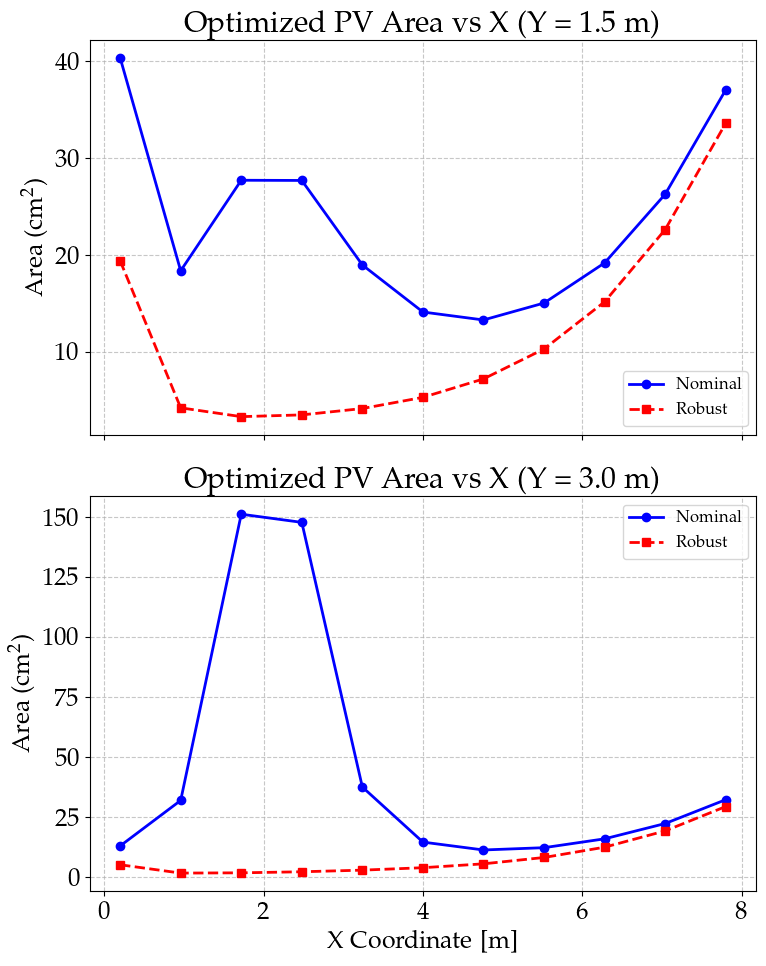

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# 1. Load the results
results_nom = np.load("area_only_cma_results_B2.npy", allow_pickle=True)
results_rob = np.load("robust_minimax_results_B2.npy")  # Columns: [X,Y,Z,...,Area(m2),...]

# 2. Extract X, Y coordinates, and areas
x_coords_nom = np.array([res['pos'][0] for res in results_nom])
y_coords_nom = np.array([res['pos'][1] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

x_coords_rob = results_rob[:, 0]
y_coords_rob = results_rob[:, 1]
areas_rob = results_rob[:, 5] * 1e4  # Convert from m² to cm²

# Get unique Y values
unique_ys = np.unique(y_coords_nom)

# 3. Create the plots (one subplot per Y)
fig, axes = plt.subplots(len(unique_ys), 1, figsize=(8, 5 * len(unique_ys)), sharex=True)

if len(unique_ys) == 1:
    axes = [axes]

for i, y_val in enumerate(unique_ys):
    # Nominal data
    mask_nom = (y_coords_nom == y_val)
    x_nom_y = x_coords_nom[mask_nom]
    areas_nom_y = areas_nom[mask_nom]
    sort_idx_nom = np.argsort(x_nom_y)

    # Robust data
    mask_rob = (y_coords_rob == y_val)
    x_rob_y = x_coords_rob[mask_rob]
    areas_rob_y = areas_rob[mask_rob]
    sort_idx_rob = np.argsort(x_rob_y)

    # Plot both datasets
    axes[i].plot(x_nom_y[sort_idx_nom], areas_nom_y[sort_idx_nom],
                 marker='o', linestyle='-', color='blue', label='Nominal')

    axes[i].plot(x_rob_y[sort_idx_rob], areas_rob_y[sort_idx_rob],
                 marker='s', linestyle='--', color='red', label='Robust')

    axes[i].set_title(rf'Optimized PV Area vs X (Y = {y_val} m)')
    axes[i].set_ylabel(r'Area (cm$^2$)')
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend(fontsize=12)

# X-axis label only for bottom subplot
axes[-1].set_xlabel(r'X Coordinate [m]')

plt.tight_layout()
plt.show()

In [6]:
100*((areas_rob - areas_cma)/areas_cma)

array([ 0.41286739,  0.45638528,  0.31015192,  0.31009929, -0.90515767,
        0.37894934,  0.42713193,  0.47434565,  0.54804904,  0.61480481,
        0.67682109,  0.50505141,  0.33970965,  0.32369011,  0.33624804,
        0.36727369,  0.41065846,  0.46413394,  0.50105372,  0.56816837,
        0.63103323,  0.69173315])

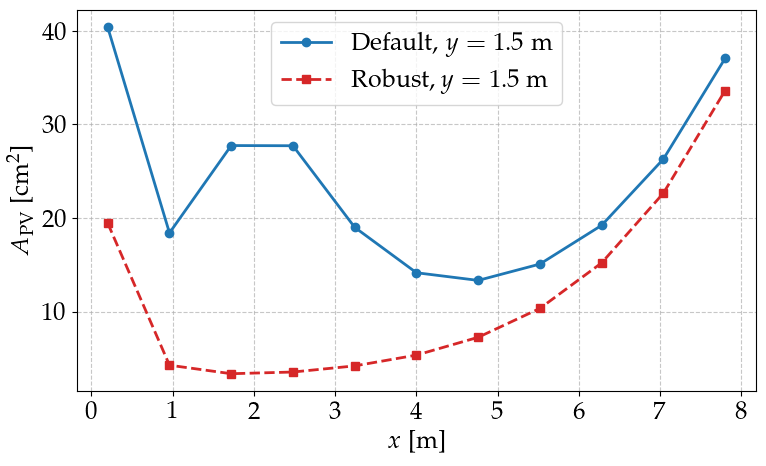

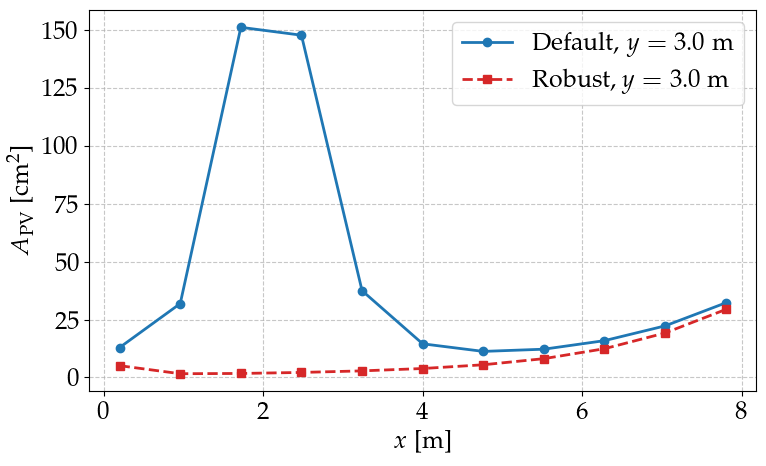

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# -----------------------
# Extract Nominal data
# -----------------------
x_nom = np.array([res['pos'][0] for res in results_nom])
y_nom = np.array([res['pos'][1] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

# -----------------------
# Extract Robust data
# -----------------------
x_rob = results_rob[:,0]
y_rob = results_rob[:,1]
areas_rob = results_rob[:,5] * 1e4  # m² → cm²

# Y values
y_vals = [1.5, 3.0]

colors = {
    'nom': 'tab:blue',
    'rob': 'tab:red'
}

# -----------------------
# Generate one plot per Y
# -----------------------
for y_val in y_vals:

    mask_nom = np.isclose(y_nom, y_val)
    mask_rob = np.isclose(y_rob, y_val)

    x_nom_y = x_nom[mask_nom]
    areas_nom_y = areas_nom[mask_nom]

    x_rob_y = x_rob[mask_rob]
    areas_rob_y = areas_rob[mask_rob]

    sort_nom = np.argsort(x_nom_y)
    sort_rob = np.argsort(x_rob_y)

    fig, ax = plt.subplots(figsize=(8,5))

    # Nominal
    ax.plot(
        x_nom_y[sort_nom],
        areas_nom_y[sort_nom],
        marker='o',
        linestyle='-',
        color=colors['nom'],
        label=rf'Default, $y={y_val}$ m'
    )

    # Robust
    ax.plot(
        x_rob_y[sort_rob],
        areas_rob_y[sort_rob],
        marker='s',
        linestyle='--',
        color=colors['rob'],
        label=rf'Robust, $y={y_val}$ m'
    )

    ax.set_xlabel(r'$x$ [m]')
    ax.set_ylabel(r'$A_\mathrm{PV}$ [cm$^2$]')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

    plt.tight_layout()

    filename = f"area_B2_{str(y_val).replace('.', 'p')}.pdf"
    plt.savefig(filename)
    plt.show()
    plt.close(fig)

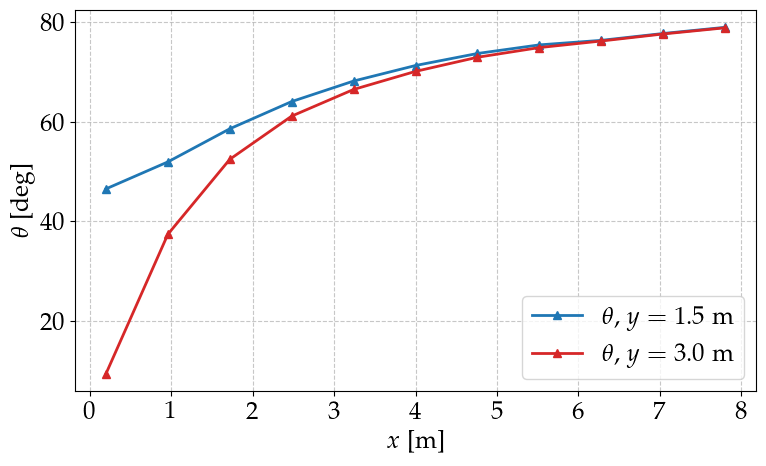

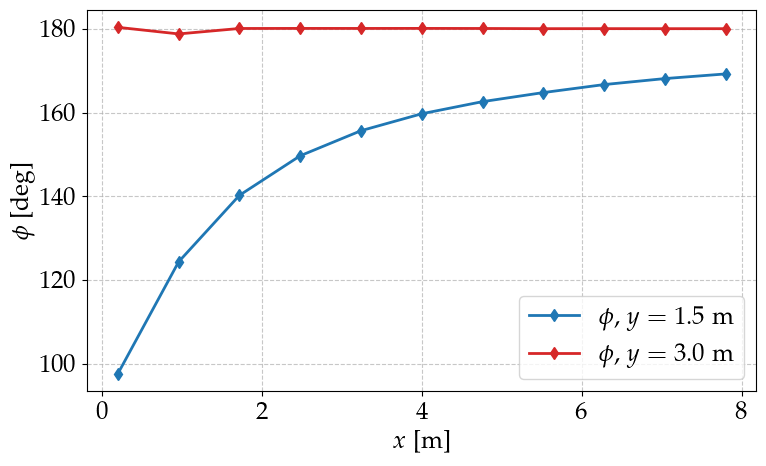

In [8]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# -----------------------
# Extract Robust data
# -----------------------
x_rob = results_rob[:, 0]
y_rob = results_rob[:, 1]

theta_rob = np.degrees(results_rob[:, 3])
phi_rob   = np.degrees(results_rob[:, 4])

# Y values to plot
y_vals = [1.5, 3.0]

# Colors per Y
colors = {1.5: 'tab:blue', 3.0: 'tab:red'}

# -----------------------
# THETA PLOT (both Y on one plot)
# -----------------------
fig, ax_theta = plt.subplots(figsize=(8,5))
for y_val in y_vals:
    mask = np.isclose(y_rob, y_val)
    x_y = x_rob[mask]
    theta_y = theta_rob[mask]
    sort_idx = np.argsort(x_y)

    ax_theta.plot(
        x_y[sort_idx],
        theta_y[sort_idx],
        marker='^',
        linestyle='-',
        color=colors[y_val],
        label=rf'$\theta$, $y={y_val}$ m'
    )

ax_theta.set_xlabel(r'$x$ [m]')
ax_theta.set_ylabel(r'$\theta$ [deg]')
ax_theta.grid(True, linestyle='--', alpha=0.7)
ax_theta.legend()
plt.tight_layout()
plt.savefig("theta_B2.pdf")
plt.show()
plt.close(fig)

# -----------------------
# PHI PLOT (both Y on one plot)
# -----------------------
fig, ax_phi = plt.subplots(figsize=(8,5))
for y_val in y_vals:
    mask = np.isclose(y_rob, y_val)
    x_y = x_rob[mask]
    phi_y = phi_rob[mask]
    sort_idx = np.argsort(x_y)

    # Shift angles > 359.5 to negative for continuity
    phi_sorted = phi_y[sort_idx]
    phi_shifted = np.where(phi_sorted > 359.5, phi_sorted - 360, phi_sorted)

    ax_phi.plot(
        x_y[sort_idx],
        phi_shifted,
        marker='d',
        linestyle='-',
        color=colors[y_val],
        label=rf'$\phi$, $y={y_val}$ m'
    )

ax_phi.set_xlabel(r'$x$ [m]')
ax_phi.set_ylabel(r'$\phi$ [deg]')
ax_phi.grid(True, linestyle='--', alpha=0.7)
ax_phi.legend()
plt.tight_layout()
plt.savefig("phi_B2.pdf")
plt.show()
plt.close(fig)